In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np
import json

In [2]:

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [4]:
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)

Launch date set to 2026-07-27 22:17:24.872990+00:00


In [5]:
# GFS - Global Forecast System for real wind data
env.set_atmospheric_model(type="Forecast", file="GFS")

/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/environment/tools.py:553: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-07-27 21:00:00 UTC instead.
  warnings.warn(


In [6]:
# motor and rocket data 

motor_data = pd.read_csv("motor.csv")
motor_config  = pd.read_json("dedalo_motor.json" , typ="series")
rocket_data = pd.read_json("dedalo_data.json", typ="series")


SolidMotor initialized successfully!


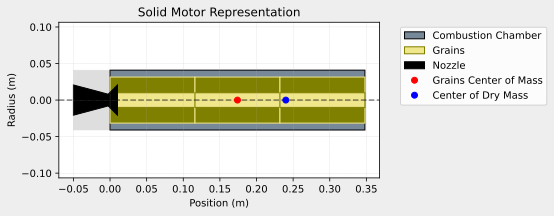

Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.008 m

Grain Details
Number of Grains: 3
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.01 m
Grain Height: 0.116 m
Grain Volume: 0.000 m3
Grain Mass: 0.569 kg

Motor Details
Total Burning Time: 2.82 s
Total Propellant Mass: 1.707 kg
Structural Mass Ratio: 0.521
Average Propellant Exhaust Velocity: 1112.480 m/s
Average Thrust: 673.437 N
Maximum Thrust: 926.4431 N at 2.79 s after ignition.
Total Impulse: 1899.091 Ns



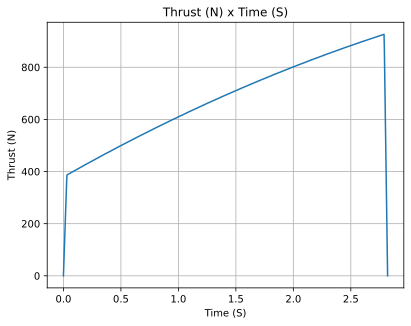

In [7]:


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=motor_data, # Use the NumPy array
    dry_mass= motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"], 
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"], 
    nozzle_position=motor_config["nozzle_position"], 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print("\nSolidMotor initialized successfully!")
Dedalo_motor.draw()
Dedalo_motor.info()

Rocket object created successfully!


/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


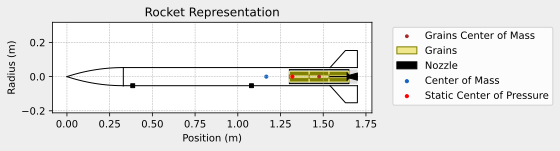

In [8]:
Dedalo_rocket = Rocket(
    radius = rocket_data["radius"],
    mass= rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia= rocket_data["inertia"],
    center_of_mass_without_motor= rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation= rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
Dedalo_rocket.add_motor(Dedalo_motor, position=1.65)

nose_cone = Dedalo_rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)

fins = Dedalo_rocket.add_trapezoidal_fins(
    n = rocket_data["n_aletas"],
    root_chord= rocket_data["root_chord"],
    tip_chord= rocket_data["tip_chord"],
    span= rocket_data["span"],
    position= rocket_data["position"],
    cant_angle= rocket_data["cant_angle"]
)

rail_buttons = Dedalo_rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

Dedalo_rocket.draw()

In [9]:
def apogee_acc_trigger(_pressure, _height, state_vector, u_dot):
    vz = state_vector[5]
    az = u_dot[5]
    return abs(vz) < 1.0 and az < -0.1

main = Dedalo_rocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=apogee_acc_trigger, 
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)

In [10]:
Dedalo_rocket.info()


Inertia Details

Rocket Mass: 4.900 kg (without motor)
Rocket Dry Mass: 6.760 kg (with unloaded motor)
Rocket Loaded Mass: 8.467 kg
Rocket Structural Mass Ratio: 0.798
Rocket Inertia (with unloaded motor) 11: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.013 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.053 m
Rocket Frontal Area: 0.008825 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.122 m
Rocket Center of Dry Mass - Nozzle Exit: 0.611 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.387 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.078 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 8.050/rad

Center of Pressure

Nose Co

In [11]:
Dedalo_flight = Flight(
    rocket=Dedalo_rocket, environment=env, rail_length=4, inclination=85, heading=0
    )

In [12]:
Dedalo_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 475.58 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.439 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.79 m/s
Lateral Surface Wind Speed: 0.77 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.387 s
Rail Departure Velocity: 15.253 m/s
Rail Departure Stability Margin: 1.490 c
Rail Departure Angle of Attack: 4.166°
Rail Departure Thrust-Weight Ratio: 5.798
Rail Departure Reynolds Number: 9.780e+04


Burn out State

Burn out time: 2.820 s
Altitude at burn out: 722.947 m (ASL) | 247.372 m (AGL)
Rocket speed at burn out: 210.701 m/s
Freestream velocity 

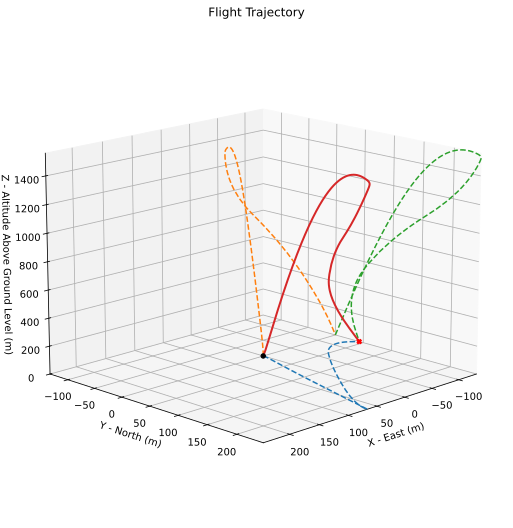

In [13]:
Dedalo_flight.plots.trajectory_3d()

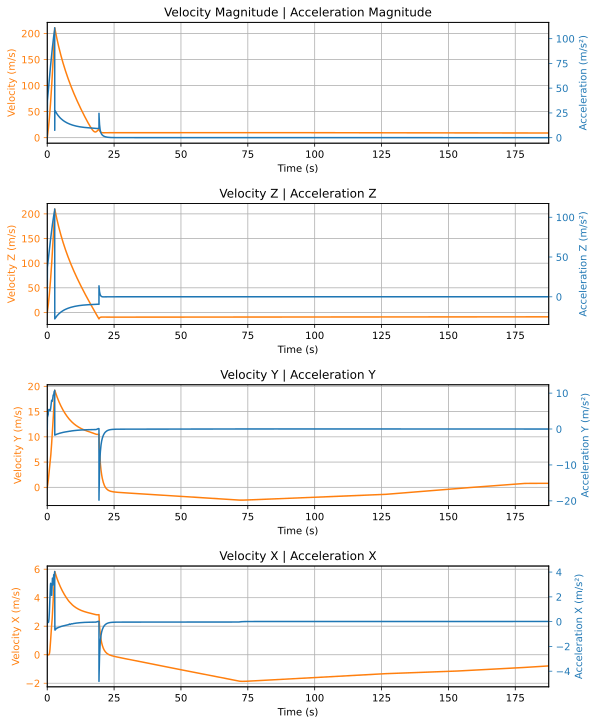

In [14]:
Dedalo_flight.plots.linear_kinematics_data()

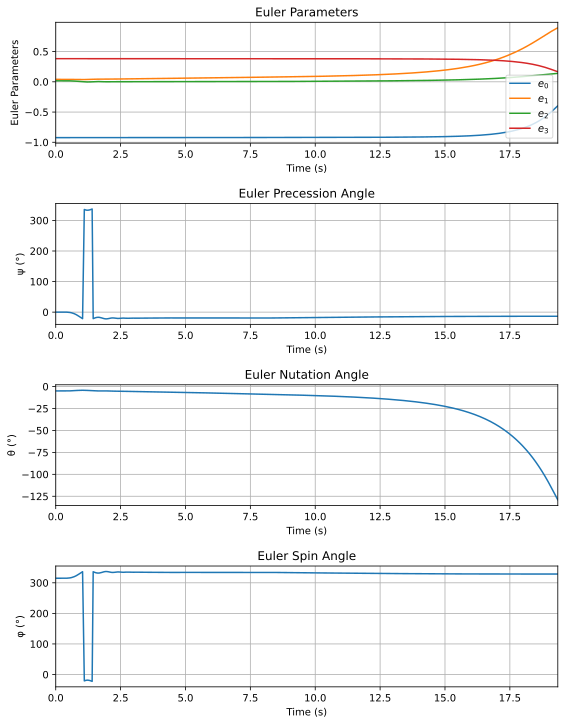

In [15]:
Dedalo_flight.plots.attitude_data()

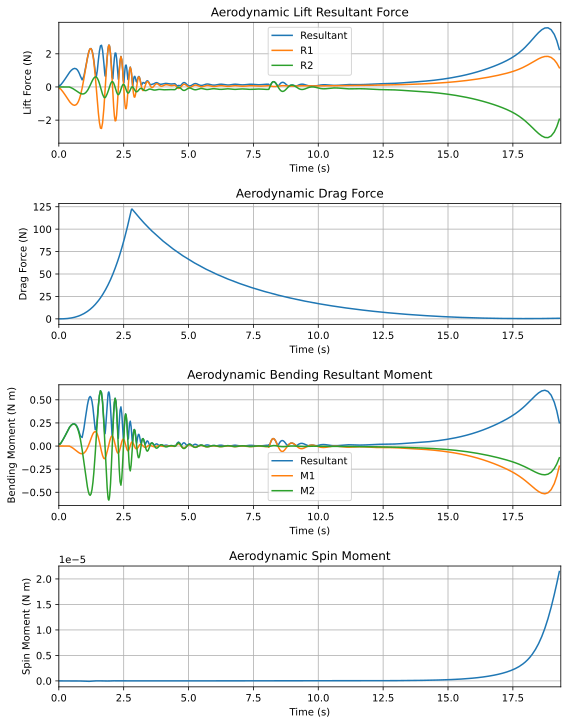

In [16]:
Dedalo_flight.plots.aerodynamic_forces()

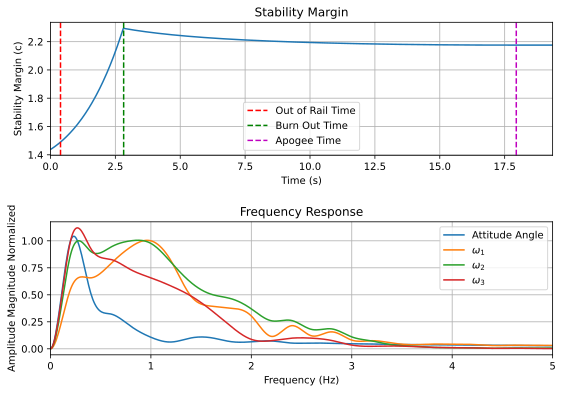

In [17]:
Dedalo_flight.plots.stability_and_control_data()

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# MONTE CARLO ANALYSIS
# ═══════════════════════════════════════════════════════════════════════

from rocketpy import MonteCarlo
from rocketpy.stochastic import (
    StochasticEnvironment,
    StochasticFlight,
    StochasticNoseCone,
    StochasticParachute,
    StochasticRocket,
    StochasticSolidMotor,
    StochasticTrapezoidalFins,
)

In [19]:
# --- Stochastic Environment ---
stochastic_env = StochasticEnvironment(
    environment=env,
    wind_velocity_x_factor=(1.0, 0.1),
    wind_velocity_y_factor=(1.0, 0.1),
)
stochastic_env.visualize_attributes()

Reporting the attributes of the `StochasticEnvironment` object:

Constant Attributes:
	datum                    SIRGAS2000
	elevation                475.5751953125
	gravity                  Function from R1 to R1 : (height (m)) → (gravity (m/s²))
	latitude                 -21.9430528
	longitude                -48.9540861
	timezone                 UTC

Stochastic Attributes:
	wind_velocity_x_factor   1.00000 ± 0.10000 (normal)
	wind_velocity_y_factor   1.00000 ± 0.10000 (normal)


'Reporting the attributes of the `StochasticEnvironment` object:\n\nConstant Attributes:\n\tdatum                    SIRGAS2000\n\televation                475.5751953125\n\tgravity                  Function from R1 to R1 : (height (m)) → (gravity (m/s²))\n\tlatitude                 -21.9430528\n\tlongitude                -48.9540861\n\ttimezone                 UTC\n\nStochastic Attributes:\n\twind_velocity_x_factor   1.00000 ± 0.10000 (normal)\n\twind_velocity_y_factor   1.00000 ± 0.10000 (normal)'

In [20]:
# --- Stochastic SolidMotor ---
stochastic_motor = StochasticSolidMotor(
    solid_motor=Dedalo_motor,
    burn_start_time=(0, 0.05, "binomial"),
    dry_mass=0.05,
    grain_density=50,
    grain_initial_height=0.001,
    grain_initial_inner_radius=0.0005,
    grain_outer_radius=0.0005,
    grain_separation=0.0005,
    grains_center_of_mass_position=0.001,
    throat_radius=0.0003,
    nozzle_radius=0.0003,
    nozzle_position=0.001,
    total_impulse=(1899, 50),
)
stochastic_motor.visualize_attributes()

Reporting the attributes of the `StochasticSolidMotor` object:

Constant Attributes:
	burn_out_time                    2.82
	center_of_dry_mass_position      0.24
	coordinate_system_orientation    nozzle_to_combustion_chamber
	dry_I_11                         0.04718349
	dry_I_12                         0
	dry_I_13                         0
	dry_I_22                         0.04718349
	dry_I_23                         0
	dry_I_33                         0.00178498
	grain_number                     3
	interpolate                      linear
	thrust_source                        Time(s)  Thrust(N)
0      0.00    0.00000
1      0.03  386.75475
2      0.06  394.22353
3      0.09  401.65516
4      0.12  409.04974
..      ...        ...
90     2.70  913.38867
91     2.73  917.77341
92     2.76  922.12488
93     2.79  926.44310
94     2.82    0.00000

[95 rows x 2 columns]

Stochastic Attributes:
	burn_start_time                  0.00000 ± 0.05000 (binomial)
	dry_mass                         

'Reporting the attributes of the `StochasticSolidMotor` object:\n\nConstant Attributes:\n\tburn_out_time                    2.82\n\tcenter_of_dry_mass_position      0.24\n\tcoordinate_system_orientation    nozzle_to_combustion_chamber\n\tdry_I_11                         0.04718349\n\tdry_I_12                         0\n\tdry_I_13                         0\n\tdry_I_22                         0.04718349\n\tdry_I_23                         0\n\tdry_I_33                         0.00178498\n\tgrain_number                     3\n\tinterpolate                      linear\n\tthrust_source                        Time(s)  Thrust(N)\n0      0.00    0.00000\n1      0.03  386.75475\n2      0.06  394.22353\n3      0.09  401.65516\n4      0.12  409.04974\n..      ...        ...\n90     2.70  913.38867\n91     2.73  917.77341\n92     2.76  922.12488\n93     2.79  926.44310\n94     2.82    0.00000\n\n[95 rows x 2 columns]\n\nStochastic Attributes:\n\tburn_start_time                  0.00000 ± 0.05000 (

In [21]:
# --- Stochastic Rocket ---
stochastic_rocket = StochasticRocket(
    rocket=Dedalo_rocket,
    radius=0.001,
    mass=(4.9, 0.2, "normal"),
    inertia_11=0.01,
    inertia_22=0.01,
    inertia_33=0.001,
    center_of_mass_without_motor=0.005,
    power_off_drag_factor=(1.0, 0.05),
    power_on_drag_factor=(1.0, 0.05),
)
stochastic_rocket.visualize_attributes()

# --- Stochastic Nose Cone ---
stochastic_nose = StochasticNoseCone(
    nosecone=nose_cone,
    length=0.001,
)

# --- Stochastic Fins ---
stochastic_fins = StochasticTrapezoidalFins(
    trapezoidal_fins=fins,
    root_chord=0.001,
    tip_chord=0.001,
    span=0.001,
)

# --- Stochastic Parachute ---
stochastic_parachute = StochasticParachute(
    parachute=main,
    cd_s=0.1,
    lag=0.2,
)

# Add components to stochastic rocket (posicao = std, nominal herdado do original)
stochastic_rocket.add_motor(stochastic_motor, position=0.001)
stochastic_rocket.add_nose(stochastic_nose, position=(0.001, "normal"))
stochastic_rocket.add_trapezoidal_fins(stochastic_fins, position=(0.001, "normal"))
stochastic_rocket.add_parachute(stochastic_parachute)

Reporting the attributes of the `StochasticRocket` object:

Constant Attributes:
	I_12_without_motor              0
	I_13_without_motor              0
	I_23_without_motor              0
	coordinate_system_orientation   nose_to_tail
	power_off_drag                  Function from R1 to R1 : (Mach Number) → (Drag Coefficient with Power Off)
	power_on_drag                   Function from R1 to R1 : (Mach Number) → (Drag Coefficient with Power On)

Stochastic Attributes:
	I_11_without_motor              1.11712 ± 0.01000 (normal)
	I_22_without_motor              1.11719 ± 0.01000 (normal)
	I_33_without_motor              0.01140 ± 0.00100 (normal)
	center_of_mass_without_motor    0.96700 ± 0.00500 (normal)
	mass                            4.90000 ± 0.20000 (normal)
	power_off_drag_factor           1.00000 ± 0.05000 (normal)
	power_on_drag_factor            1.00000 ± 0.05000 (normal)
	radius                          0.05300 ± 0.00100 (normal)


In [22]:
# --- Stochastic Flight ---
stochastic_flight = StochasticFlight(
    flight=Dedalo_flight,
    inclination=(85, 1),    # media=85, std=1 grau
    heading=(0, 2),         # media=0, std=2 graus
)
stochastic_flight.visualize_attributes()

Reporting the attributes of the `StochasticFlight` object:

Constant Attributes:
	rail_length           4

Stochastic Attributes:
	heading               0.00000 ± 2.00000 (normal)
	inclination           85.00000 ± 1.00000 (normal)


'Reporting the attributes of the `StochasticFlight` object:\n\nConstant Attributes:\n\trail_length           4\n\nStochastic Attributes:\n\theading               0.00000 ± 2.00000 (normal)\n\tinclination           85.00000 ± 1.00000 (normal)'

In [23]:
mc_dedalo = MonteCarlo(
    filename="monte_carlo_dedalo_output",
    environment=stochastic_env,
    rocket=stochastic_rocket,
    flight=stochastic_flight,
)

# Roda 500 simulacoes em paralelo (4 workers)
mc_dedalo.simulate(
    number_of_simulations=500,
    append=False,
    include_function_data=False,
    parallel=True,
    n_workers=4,
)

The following input file was imported: monte_carlo_dedalo_output.inputs.txt
A total of 500 simulation results were loaded from: monte_carlo_dedalo_output.outputs.txt
The following error file was imported: monte_carlo_dedalo_output.errors.txt
Starting Monte Carlo analysis
Running Monte Carlo simulation with 4 workers.


/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/simulation/monte_carlo.py:139: UserWarning: This class is still under testing and some attributes may be changed in next versions
  warnings.warn(


Iterations completed: 000001 | Average Time per Iteration: 0.712 s | Estimated time left: 355 s

Iterations completed: 000002 | Average Time per Iteration: 0.360 s | Estimated time left: 179 s

Iterations completed: 000003 | Average Time per Iteration: 0.251 s | Estimated time left: 124 s

...

Iterations completed: 000498 | Average Time per Iteration: 0.226 s | Estimated time left: 0 s

Iterations completed: 000499 | Average Time per Iteration: 0.226 s | Estimated time left: 0 s

Iterations completed: 000500 | Average Time per Iteration: 0.226 s | Estimated time left: 0 s

Completed 500 iterations. In total, 500 simulations are exported.
Total wall time: 112.8 s   

Results saved to monte_carlo_dedalo_output.outputs.txt


In [24]:
mc_dedalo.prints.all()

Monte Carlo Simulation by RocketPy
Data Source:  monte_carlo_dedalo_output
Number of simulations:  500
Results: 

                Parameter            Mean          Median       Std. Dev.    95% PI Lower    95% PI Upper
--------------------------------------------------------------------------------------------------------------
         out_of_rail_time           0.467           0.466           0.011           0.445           0.488
     lateral_surface_wind           0.777           0.775           0.079           0.621           0.925
 initial_stability_margin           1.439           1.437           0.068           1.311           1.563
     out_of_rail_velocity          19.012          18.947           0.386          18.352          19.929
          impact_velocity          -8.904          -8.913           0.330          -9.564          -8.285
                 apogee_y         217.099         218.845          57.088         107.413         337.641
     frontal_surface_wind        

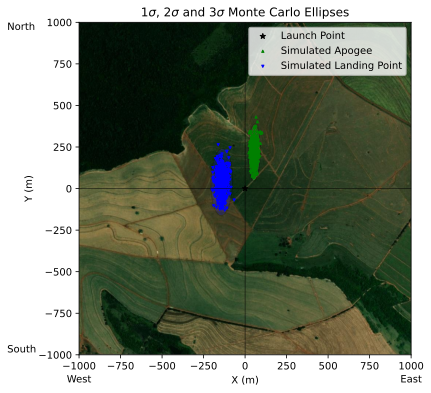

In [25]:
# Elipses de dispersao do ponto de impacto
# mc_dedalo.plots.ellipses()
mc_dedalo.plots.ellipses(background="satellite", xlim=(-1000, 1000), ylim=(-1000, 1000))

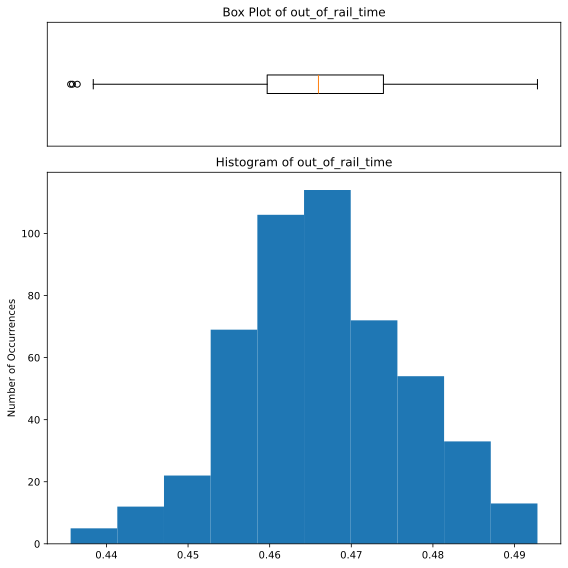

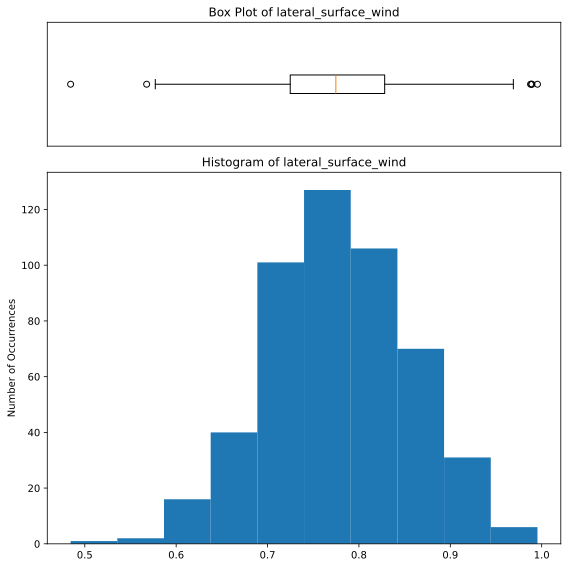

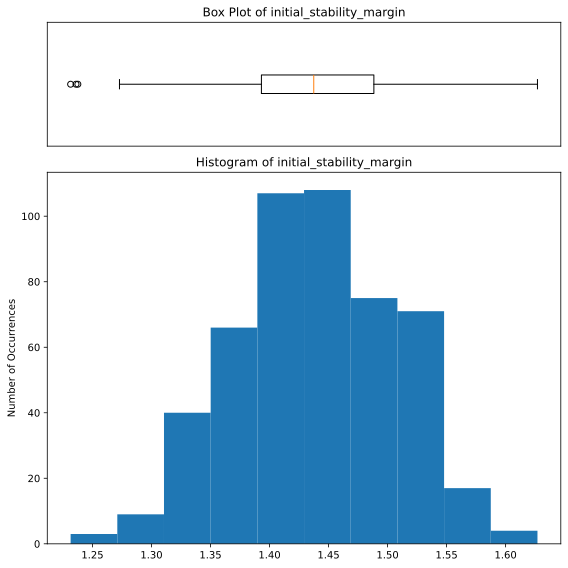

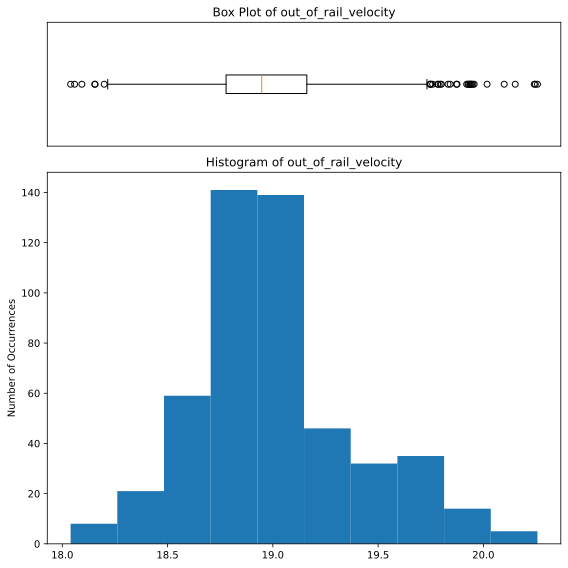

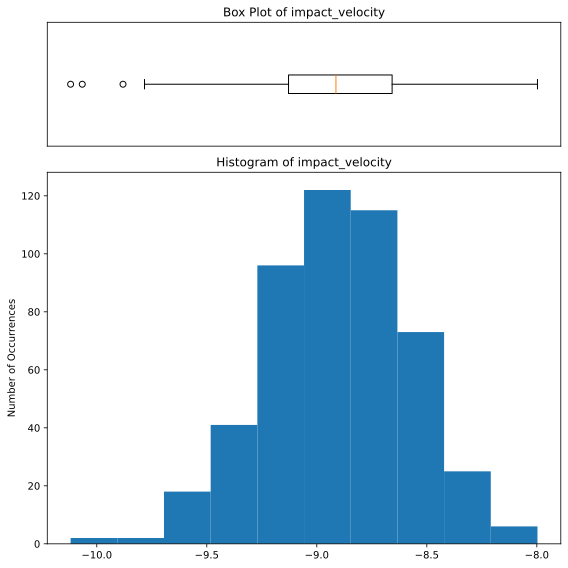

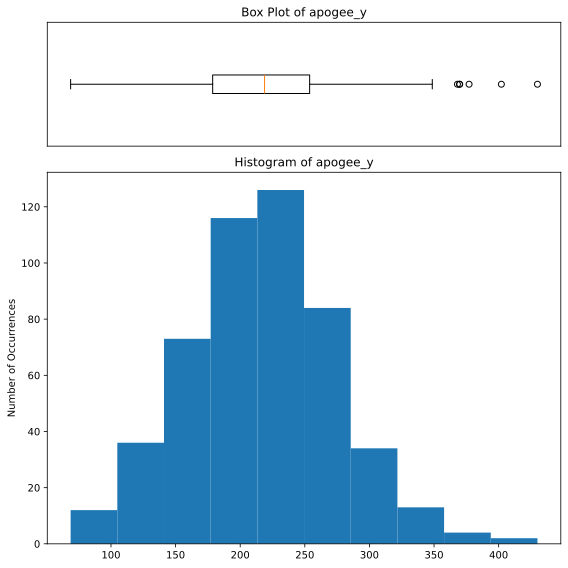

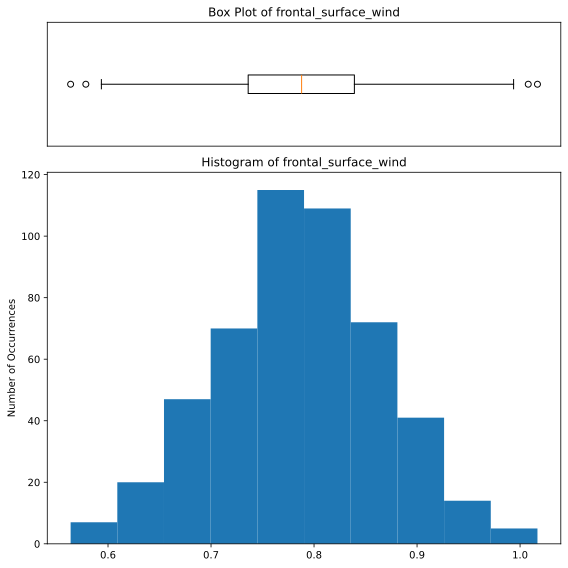

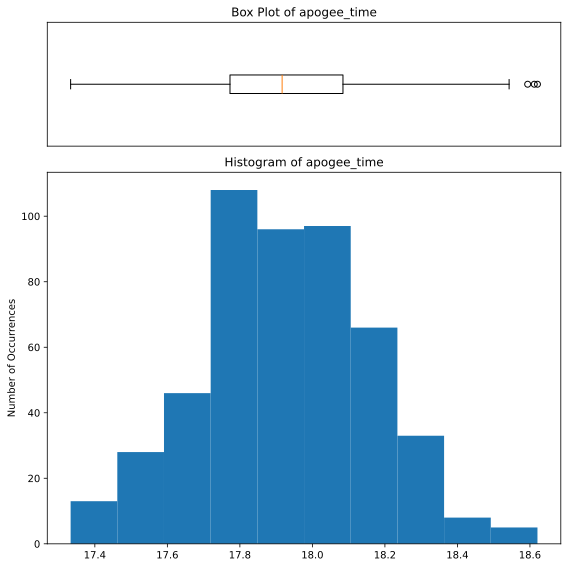

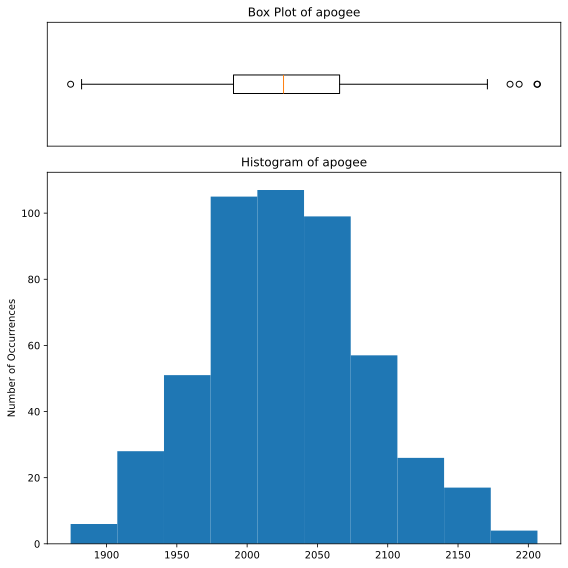

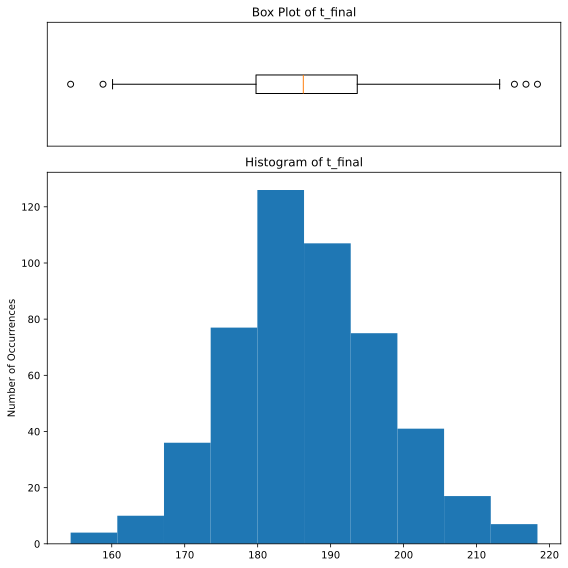

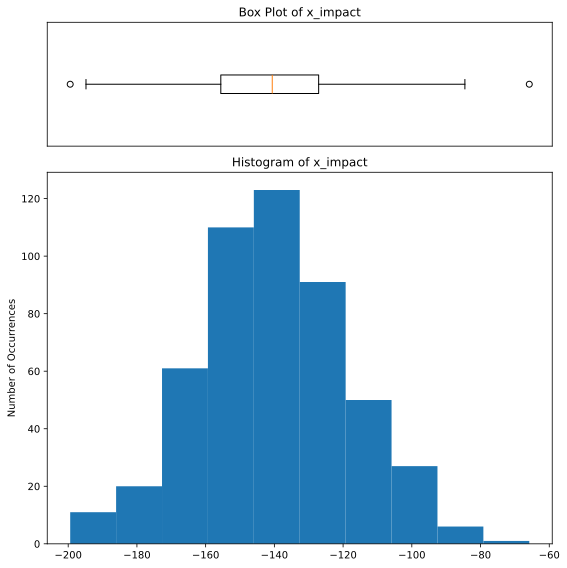

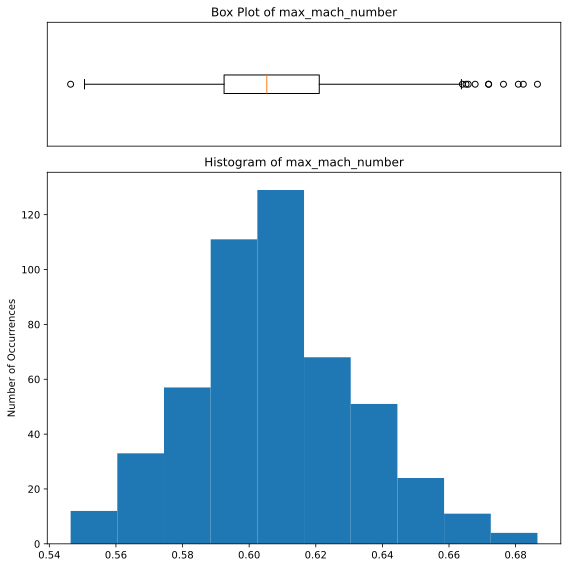

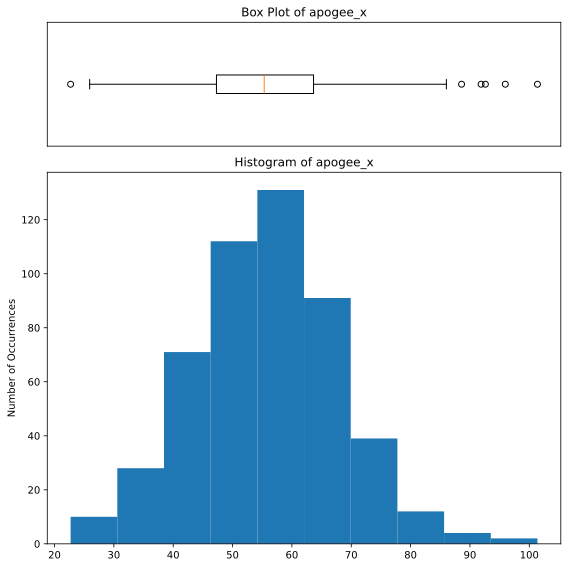

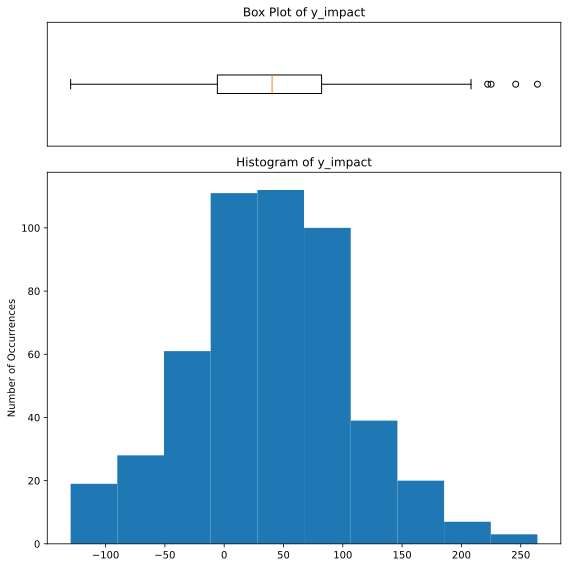

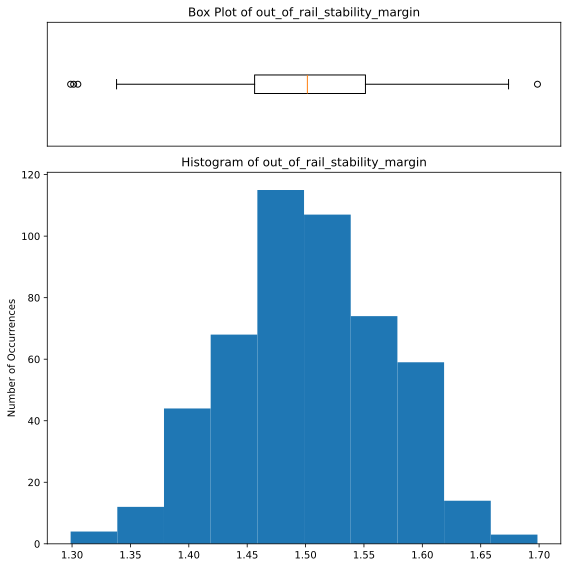

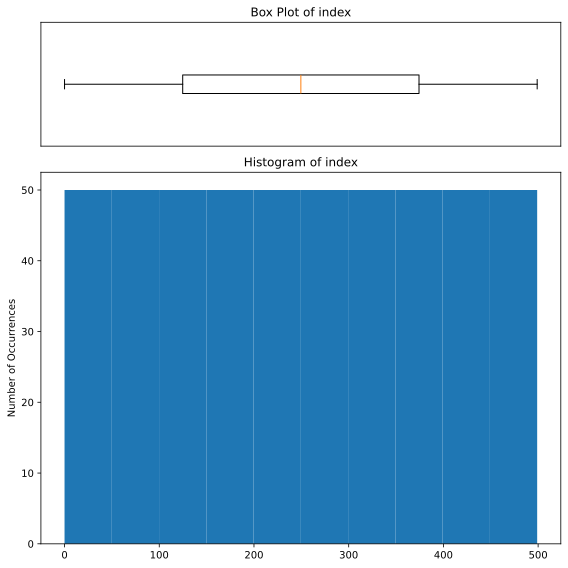

In [26]:
# Todos os graficos de dispersao
mc_dedalo.plots.all()

In [27]:
# Exportar elipses para Google Earth (.kml)
# Descomente para gerar o arquivo KML
# mc_dedalo.export_ellipses_to_kml(
#     filename="monte_carlo_dedalo_ellipses.kml",
#     origin_lat=env.latitude,
#     origin_lon=env.longitude,
#     type="impact",
# )